### ARIMA Modeling: Austrian Electricity Prices
by Paul Ringler

This is a short recap of EDA results so far.
#### Time Series Characteristics

**Outcome to be modelled:** Monthly electricity prices (2015-01 to 2025-09, N=128)
- **Variable:** `price_combined` (EXAA Day-Ahead + MC Auction average)
- **Overall Mean:** 78.09 EUR/MWh, Std: 76.83 EUR/MWh
- **Range:** 18.0 - 488.0 EUR/MWh

**Structural Breaks:**
- COVID-19 price dip detected at 2020-01 (Ziv-Andrews test)
- Main crisis escalation at 2021-09 (Ukraine war)

**Assumed Regime Structure** (identified via EDA, addressed in Feature Engineering):
- Stable Pre-Shock (2015-01 to 2020-12, n=72): Stationary (ADF p=0.034)
- Price Shock (2021-01 to 2023-02, n=26): Non-stationary, extreme volatility
- Stable Post-Shock (2023-03 to 2025-08, n=30): Stationary (ADF p=0.027)

- Full series: Non-stationary (ADF p=0.14, KPSS p=0.012)
 

**Stationarity and Impact of Structural Break:**
- Complete series: Slow ACF decay (non-stationary) due to level shifts between periods
- Individual stable periods: Fast exponential decay, PACF cutoff at lag 1-2 (AR structure)
- PACF suggests AR(1) or AR(2) within stable periods
- Modeling strategy: Test on complete series first, then evaluate need for period-specific models

**Seasonality:**
- Moderate seasonal strength (0.36)
- Multiplicative seasonal pattern (±20% around trend)
- Peak: December (96.85), Trough: May (57.00)

---

#### Modeling Assumptions

1. **Differencing:** d=1 required (confirmed by ADF/KPSS)
2. **AR/MA Structure:** Grid search for p,q ∈ {0,1,2}. PACF suggests AR(1) or AR(2) as starting point.
1. **Stationarity Approach:** Test ARIMA on complete series first (structural breaks will challenge this). ARIMAX and period-specific modeling if necessary.
4. **Train-Test Split:** Temporal split (no random shuffle)
   - Train: 2015-01 to 2023-12 (N=108)
   - Test: 2024-01 to 2025-06 (N=18)
   **Note:** Training on the pre-shock and shock-periods reflects a real-world scenario where structural breaks cannot be excluded ex-ante and a "new-normal" needs forecasting.
5. **Model Selection Criteria:** AIC/BIC (in-sample) + RMSE/MAE (out-of-sample)

---

#### Modeling Strategy

**Phase 1: Baseline Models (Complete Series)**
- Persistence (ŷ_t = y_{t-1})
- Seasonal Naive (ŷ_t = y_{t-12})

**Phase 2: Univariate ARIMA**
- ARIMA(p,d,q) via grid search (p,q ∈ {0,1,2}, d ∈ {0,1})
- **Expected:** Poor performance due to structural breaks
- **Purpose:** Baseline model to test if exogenous variables provide sufficient information for improved prognosis
- Residual diagnostics (ACF, Ljung-Box, normality)

**Phase 3: ARIMAX with Single Exogenous Variables (Complete Series)**
Individual models to test incremental improvement and avoid multicollinearity:
- ARIMAX + Gas prices (`oegpi_month`) - strongest predictor (r=0.84)
- ARIMAX + CO2 prices (`carbonprices_primary_market`) - moderate (r=0.70)
- ARIMAX + Climate (`climate_hdd_at`, `climate_cdd_at`) - test despite weak correlation
- ARIMAX + Imports (`econ_imports_total_EUR`) - demand proxy (r=0.70)

**Excluded variables due to multicollinearity or irrelevance:**
- `econ_imports_energy_EUR`: Nearly redundant with gas prices (r=0.91)
- `econ_exports_total_EUR`: Nearly redundant with imports (r=0.96)
- `econ_count_overnight_stays`: No correlation with price (r=0.08)
- `prod_renewables_pct_total`: No correlation with price (r=-0.02)
- `econ_consumer_price_index`: High correlation with CO2 (r=0.86), inflation proxy less relevant

**Phase 4: ARIMAX with Combined Exogenous Variables**
Test combinations to maximize explanatory power while avoiding multicollinearity:
- ARIMAX + Gas + CO2
- ARIMAX + Gas + CO2 + Climate
- ARIMAX + Gas + CO2 + Imports (check coefficient stability due to CO2-Imports correlation r=0.88)

**Selection criteria:**
- AIC/BIC improvement vs. single-variable models
- Coefficient sign stability (expected: Gas+, CO2+, HDD+, CDD+, Imports+)
- Standard errors remain reasonable

**Phase 5: Validation**
- Time Series Cross-Validation (rolling/expanding window)
- Final model selection and forecast


---

#### Exogenous Variables - Expected Effects 

**Multicollinearity Assessment (Correlation Analysis):**
Critical correlations identified:
- Gas ↔ Energy Imports: r=0.91 → Energy Imports excluded
- Exports ↔ Imports Total: r=0.96 → Exports excluded  
- CO2 ↔ Imports: r=0.88 → Monitor in combined models
- HDD ↔ Renewables: r=-0.85 → Causal link, both retained

Weak/No correlation with price:
- Climate variables (HDD: r=-0.01, CDD: r=0.02) → Test for non-linear effects
- Renewables share (r=-0.02) → Excluded
- Overnight stays (r=0.08) → Excluded

**Primary Driver:**
- **Gas Prices** (`oegpi_month`): **Strong** effect expected
  - Gas is a marginal fuel in Austria and sets electricity price
  - Pre-shock correlation: moderate, Post-shock: high
  
  **Secondary Drivers:**
- **CO2 Prices** (`carbonprices_primary_market`):**Moderate** effect expected
  - EU ETS increases fossil generation costs
  - Effect stronger when fossil share is high. Since share of renewable energy in Austria ranges seasonally from ~70% to ~90% this effect is expected to be rather small.

- **Climate** (`climate_hdd_at`, `climate_cdd_at`): **Moderate** effect
  - Heating Degree Days → winter demand ↑
  - Cooling Degree Days → summer demand ↑
  
- **Production Mix** (`prod_renewable_*`, `prod_fossil_*`): **Complex** effect expected
  - High renewable generation → lower prices (merit order)
  - Fossil production usually correlates with high demand periods, may be offset by Austria´s substantial 
pumped storage power plants capacities.

- **Economic Indicators** (`econ_prod_index_industry`): **Complex** effects expected
No monthly measure of GDP growth was available and critical data such as industrial production is only available for a few months. Expectations for data available for the period of analysis:
  - Exports total, Overnight stays, Consumer Price Index: Proxy variables for economic climate. Will be tested for effect. Weak effect expected
  - Imports and Energy Imports: Strong effect expected, also multicollinearity between the two.


**Hypothesis:** Gas prices will explain most variance (r=0.84). CO2 prices provide 
secondary contribution (r=0.70). Climate variables and Imports may add marginal 
improvement despite weak bivariate correlations (potential interaction effects).
---

**Note on Test Data:**
Test period limited to 2024-01 to 2025-06 (18 months) due to exogenous 
variable availability. Climate variables for 2025 (HDD/CDD) filled with 
2024 values under the assumption of stable year-over-year climate patterns.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Load data
df = pd.read_csv(r'../../data/processed/data_analysis_ready.csv', 
                 encoding='cp1252',  # to account for regional data settings
                 parse_dates=['date_dt']) # data is csv, date_dt needs to be parsed as date on loading

#keep monthly data only
df = df[df['aggregation_level'] == 'monthly'].copy()

#set datetime index
df = df.set_index('date_dt') 
print(f"Index type: {type(df.index)}")
print(f"Index range: {df.index.min()} to {df.index.max()}")

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index range: 2015-01-01 00:00:00 to 2025-08-01 00:00:00


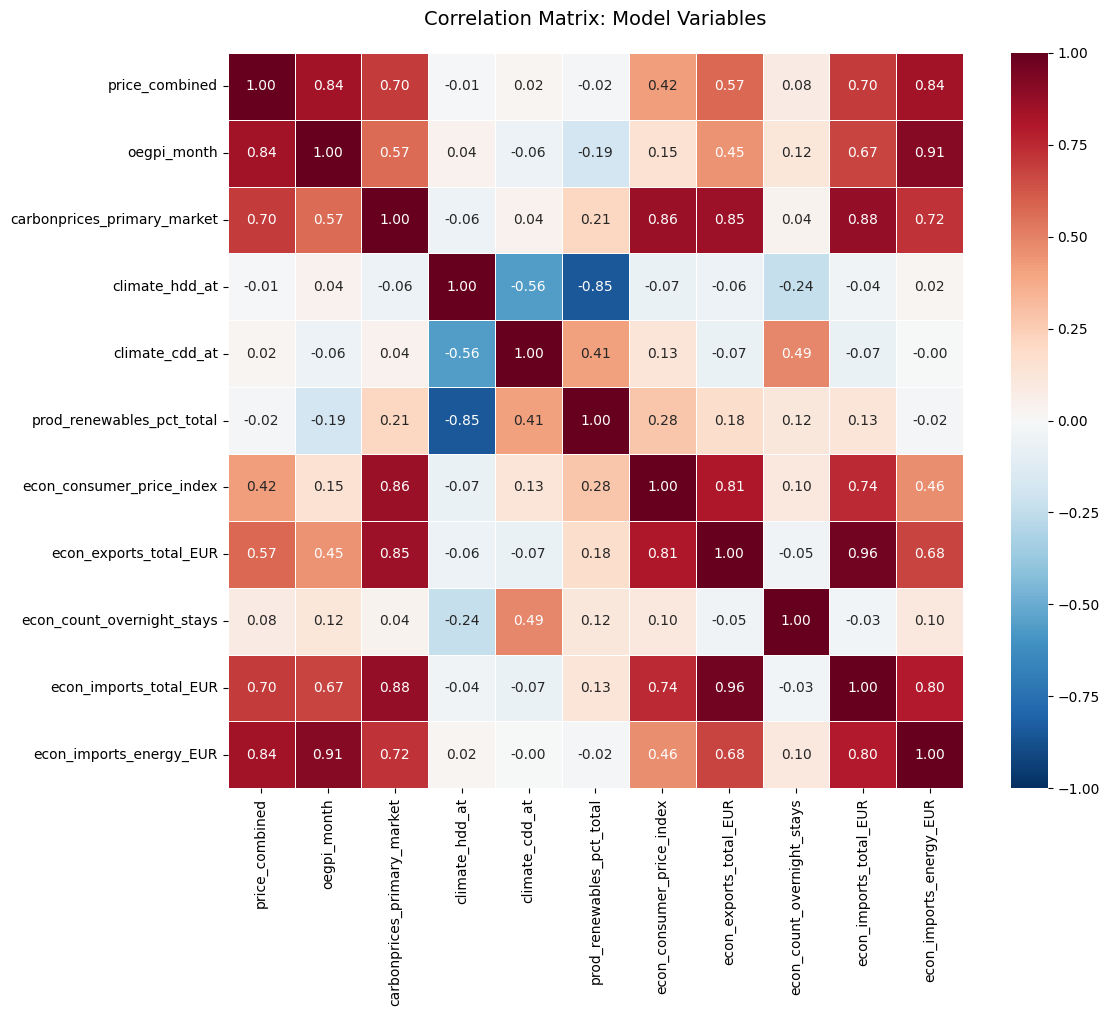


High Correlations (|r| > 0.7):
price_combined                 ↔ oegpi_month                   :  0.84
price_combined                 ↔ econ_imports_total_EUR        :  0.70
price_combined                 ↔ econ_imports_energy_EUR       :  0.84
oegpi_month                    ↔ econ_imports_energy_EUR       :  0.91
carbonprices_primary_market    ↔ econ_consumer_price_index     :  0.86
carbonprices_primary_market    ↔ econ_exports_total_EUR        :  0.85
carbonprices_primary_market    ↔ econ_imports_total_EUR        :  0.88
carbonprices_primary_market    ↔ econ_imports_energy_EUR       :  0.72
climate_hdd_at                 ↔ prod_renewables_pct_total     : -0.85
econ_consumer_price_index      ↔ econ_exports_total_EUR        :  0.81
econ_consumer_price_index      ↔ econ_imports_total_EUR        :  0.74
econ_exports_total_EUR         ↔ econ_imports_total_EUR        :  0.96
econ_imports_total_EUR         ↔ econ_imports_energy_EUR       :  0.80


In [ ]:
#correlation matrix of exogenous variables


import seaborn as sns
import matplotlib.pyplot as plt

# Define model variables
model_vars = [
    'price_combined',
    'oegpi_month',
    'carbonprices_primary_market',
    'climate_hdd_at',
    'climate_cdd_at',
    'prod_renewables_pct_total',
    'econ_consumer_price_index',
    'econ_exports_total_EUR',
    'econ_count_overnight_stays',
    'econ_imports_total_EUR',
    'econ_imports_energy_EUR'
]

# Calculate correlation matrix
corr = df[model_vars].corr()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Model Variables', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Print high correlations (|r| > 0.7)
print("\nHigh Correlations (|r| > 0.7):")
print("="*50)
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"{corr.columns[i]:30s} ↔ {corr.columns[j]:30s}: {corr.iloc[i, j]:5.2f}")

##### Train-Test Split

In [16]:
# Temporal train-test split
# Adjusted test period to match data availability
split_date = '2023-12'
test_end = '2025-06'  # Where most exogenous variables end

train = df[df.index <= split_date].copy()
test = df[(df.index > split_date) & (df.index <= test_end)].copy()

print(f"Train: {train.index.min()} to {train.index.max()} (n={len(train)})")
print(f"Test:  {test.index.min()} to {test.index.max()} (n={len(test)})")

Train: 2015-01-01 00:00:00 to 2023-12-01 00:00:00 (n=108)
Test:  2024-01-01 00:00:00 to 2025-06-01 00:00:00 (n=18)


##### Baseline models

In [18]:
# Baseline 1: Persistence (same as yesterday)
persistence_pred = train.iloc[-1]  # Last value of train
persistence_forecast = np.full(len(test), persistence_pred)

# Baseline 2: Seasonal Naive (same month last year)
seasonal_naive_forecast = []
for i in range(len(test)):
    # Get value from 12 months ago in train
    if len(train) >= 12:
        seasonal_naive_forecast.append(train.iloc[-(12-i)])
    else:
        seasonal_naive_forecast.append(train.mean())

seasonal_naive_forecast = np.array(seasonal_naive_forecast)

# Calculate RMSE
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse_pers = np.sqrt(mean_squared_error(test, persistence_forecast))
mae_pers = mean_absolute_error(test, persistence_forecast)
mape_pers = mean_absolute_percentage_error(test, persistence_forecast) * 100
bias_pers = np.mean(persistence_forecast - test)
max_error_pers = np.max(np.abs(persistence_forecast - test))

rmse_seas = np.sqrt(mean_squared_error(test, seasonal_naive_forecast))
mae_seas = mean_absolute_error(test, seasonal_naive_forecast)
mape_seas = mean_absolute_percentage_error(test, seasonal_naive_forecast) * 100
bias_seas = np.mean(seasonal_naive_forecast - test)
max_error_seas = np.max(np.abs(seasonal_naive_forecast - test))

print("BASELINE MODEL PERFORMANCE:")
print(f"Persistence:    RMSE={rmse_pers:.2f}, MAE={mae_pers:.2f}, MAPE={mape_pers:.1f}%, Bias={bias_pers:.2f}, Max Error={max_error_pers:.2f}")
print(f"Seasonal Naive: RMSE={rmse_seas:.2f}, MAE={mae_seas:.2f}, MAPE={mape_seas:.1f}%, Bias={bias_seas:.2f}, Max Error={max_error_seas:.2f}")

ValueError: could not broadcast input array from shape (44,) into shape (18,)

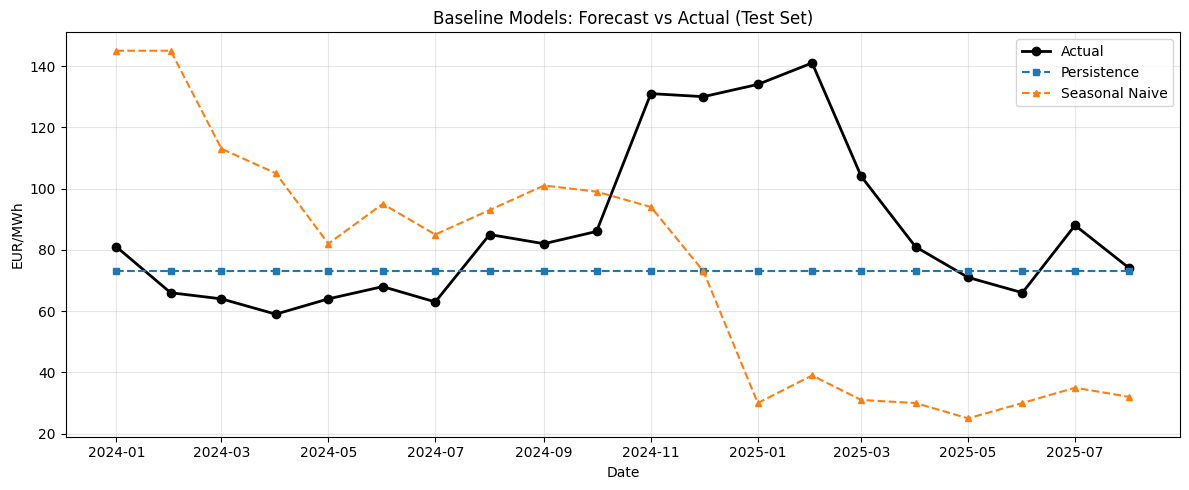

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 5))

# Plot actual test values
ax.plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=2, markersize=6, color='black')

# Plot forecasts
ax.plot(y_test.index, persistence_forecast, 's--', label='Persistence', linewidth=1.5, markersize=5)
ax.plot(y_test.index, seasonal_naive_forecast, '^--', label='Seasonal Naive', linewidth=1.5, markersize=5)

ax.set_xlabel('Date')
ax.set_ylabel('EUR/MWh')
ax.set_title('Baseline Models: Forecast vs Actual (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Phase 2: Univariate ARIMA - Grid Search
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox  # <-- Missing import
from scipy import stats

models_to_test = [
    (2, 1, 0),  # Pure AR(2) - PACF cutoff at lag 2
    (1, 1, 1),  # Simple ARMA
    (2, 1, 1),  # AR(2) + MA(1)
    (2, 1, 2),  # Full ARMA(2,2)
]

results = []

for order in models_to_test:
    try:
        model = ARIMA(y_train, order=order)
        fit = model.fit()
        
        # Forecast on test set
        forecast = fit.forecast(steps=len(y_test))
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        mae = mean_absolute_error(y_test, forecast)
        mape = mean_absolute_percentage_error(y_test, forecast) * 100
        bias = np.mean(forecast - y_test)
        max_error = np.max(np.abs(forecast - y_test))
        
        results.append({
            'order': order,
            'aic': fit.aic,
            'bic': fit.bic,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'bias': bias,
            'max_error': max_error,
            'model': fit,
            'forecast': forecast  # <-- Now included!
        })
        
        print(f"ARIMA{order}: AIC={fit.aic:.2f}, BIC={fit.bic:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
        
    except Exception as e:
        print(f"ARIMA{order}: Failed - {e}")

# Best model by AIC
best_model = min(results, key=lambda x: x['aic'])
print(f"\nBest model by AIC: ARIMA{best_model['order']}")
print(f"  RMSE={best_model['rmse']:.2f}, MAE={best_model['mae']:.2f}, MAPE={best_model['mape']:.1f}%, Bias={best_model['bias']:.2f}, Max Error={best_model['max_error']:.2f}")

# Visualize best ARIMA forecast
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=2, color='black')
ax.plot(y_test.index, best_model['forecast'], 's--', label=f'ARIMA{best_model["order"]}', linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('EUR/MWh')
ax.set_title('Univariate ARIMA: Forecast vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ARIMA(2, 1, 0): Failed - name 'y_train' is not defined
ARIMA(1, 1, 1): Failed - name 'y_train' is not defined
ARIMA(2, 1, 1): Failed - name 'y_train' is not defined
ARIMA(2, 1, 2): Failed - name 'y_train' is not defined


ValueError: min() iterable argument is empty

In [ ]:
# Phase 2: Univariate ARIMA -
# RESIDUAL DIAGNOSTICS (Best Model)

best_fit = best_model['model']
residuals = best_fit.resid

print("\n" + "="*50)
print("RESIDUAL DIAGNOSTICS - BEST MODEL")
print("="*50)

# Ljung-Box Test (no autocorrelation in residuals)
lb_test = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("\nLjung-Box Test (H0: No autocorrelation):")
print(lb_test)

# Normality Test (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test (H0: Normal distribution):")
print(f"  Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# ACF/PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=24, ax=axes[0], alpha=0.05)
axes[0].set_title(f'Residuals ACF - ARIMA{best_model["order"]}')

plot_pacf(residuals, lags=24, ax=axes[1], alpha=0.05)
axes[1].set_title(f'Residuals PACF - ARIMA{best_model["order"]}')

plt.tight_layout()
plt.show()

NameError: name 'best_model' is not defined

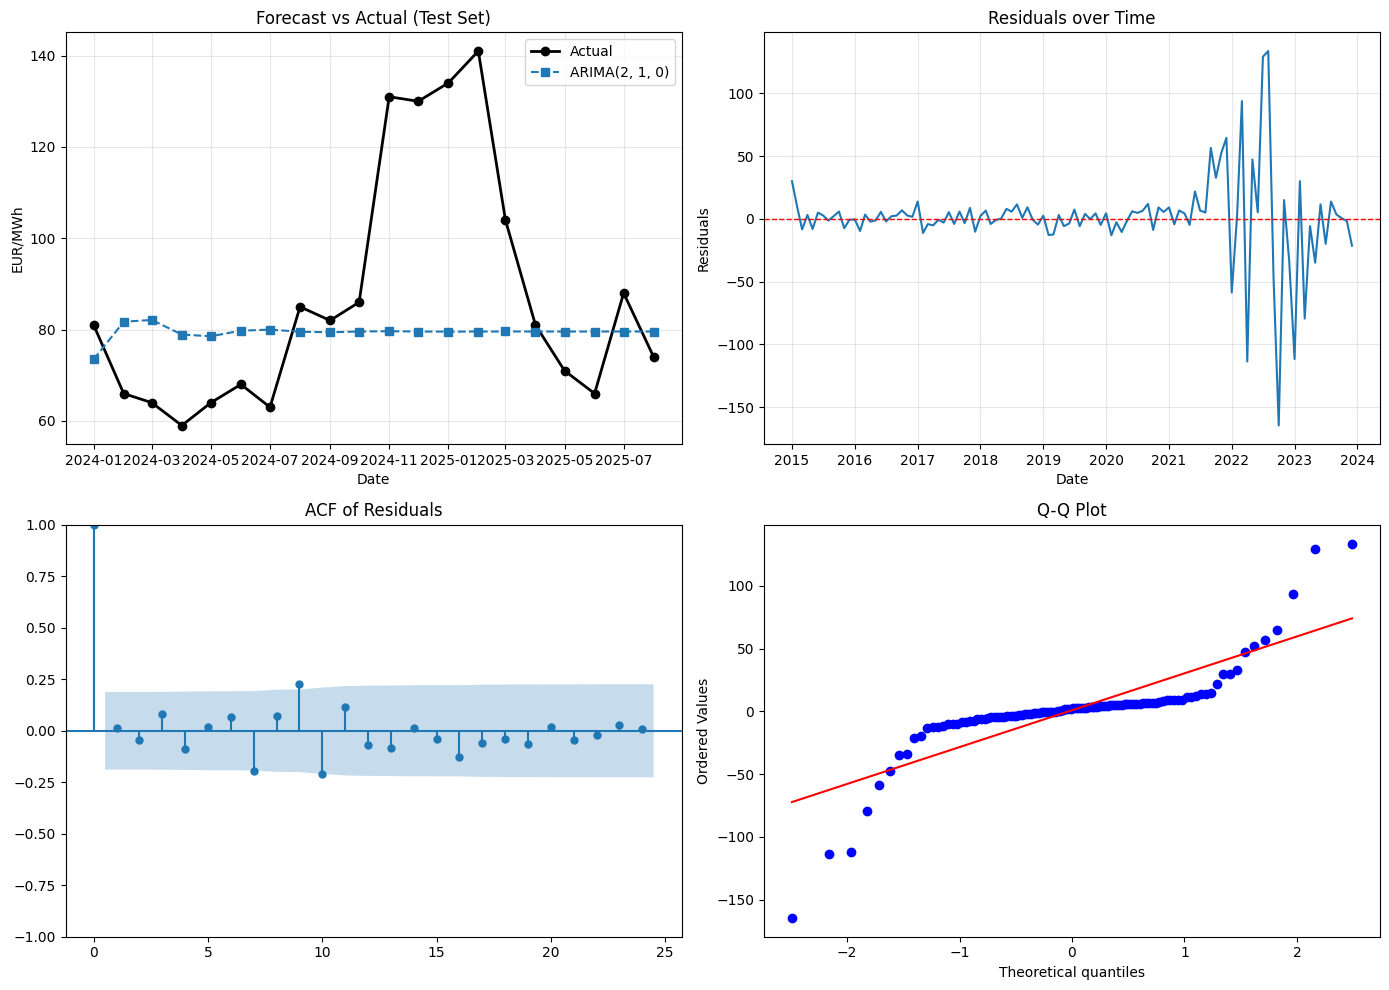

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Forecast vs Actual
axes[0, 0].plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=2, color='black')
axes[0, 0].plot(y_test.index, best_model['forecast'], 's--', label=f"ARIMA{best_model['order']}", linewidth=1.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('EUR/MWh')
axes[0, 0].set_title('Forecast vs Actual (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals over time
axes[0, 1].plot(residuals.index, residuals.values)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals over Time')
axes[0, 1].grid(True, alpha=0.3)

# 3. ACF of residuals
plot_acf(residuals, lags=24, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals')

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE 3: ARIMAX WITH REGIME DUMMIES
# ============================================

# Ensure train and test have same indices
print("DATA ALIGNMENT CHECK:")
print(f"y_train: n={len(y_train)}, index: {y_train.index.min()} to {y_train.index.max()}")
print(f"y_test:  n={len(y_test)}, index: {y_test.index.min()} to {y_test.index.max()}")

# Prepare exogenous variables with same indices
exog_train = train[['regime_shock', 'regime_post']]
exog_test = test[['regime_shock', 'regime_post']]

print(f"exog_train: shape={exog_train.shape}")
print(f"exog_test:  shape={exog_test.shape}")

# Align y_test with exog_test (in case of mismatch)
common_index = y_test.index.intersection(exog_test.index)
y_test_aligned = y_test.loc[common_index]
exog_test_aligned = exog_test.loc[common_index]

print(f"\nAfter alignment:")
print(f"y_test_aligned:  n={len(y_test_aligned)}")
print(f"exog_test_aligned: shape={exog_test_aligned.shape}")

# Use aligned versions
y_test = y_test_aligned
exog_test = exog_test_aligned

print("\n" + "="*50)
print("PHASE 3: ARIMAX with Regime Dummies")
print("="*50)

models_arimax = [
    (2, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (2, 1, 2),
]

results_arimax = []

for order in models_arimax:
    try:
        model = ARIMA(y_train, exog=exog_train, order=order)
        fit = model.fit()
        
        # Forecast with exog
        forecast = fit.forecast(steps=len(y_test), exog=exog_test)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        mae = mean_absolute_error(y_test, forecast)
        mape = mean_absolute_percentage_error(y_test, forecast) * 100
        bias = np.mean(forecast - y_test)
        max_error = np.max(np.abs(forecast - y_test))
        
        results_arimax.append({
            'order': order,
            'aic': fit.aic,
            'bic': fit.bic,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'bias': bias,
            'max_error': max_error,
            'model': fit,
            'forecast': forecast
        })
        
        print(f"ARIMAX{order}: AIC={fit.aic:.2f}, BIC={fit.bic:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
        
    except Exception as e:
        print(f"ARIMAX{order}: Failed - {e}")

# Check if any models succeeded
if len(results_arimax) == 0:
    print("\nERROR: All ARIMAX models failed!")
else:
    # Continue with best model selection...
    best_arimax = min(results_arimax, key=lambda x: x['aic'])
    print(f"\nBest ARIMAX model by AIC: ARIMAX{best_arimax['order']}")
    print(f"  RMSE={best_arimax['rmse']:.2f}, MAE={best_arimax['mae']:.2f}, MAPE={best_arimax['mape']:.1f}%")

DATA ALIGNMENT CHECK:
y_train: n=108, index: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
y_test:  n=20, index: 2024-01-01 00:00:00 to 2025-08-01 00:00:00
exog_train: shape=(108, 2)
exog_test:  shape=(18, 2)

After alignment:
y_test_aligned:  n=18
exog_test_aligned: shape=(18, 2)

PHASE 3: ARIMAX with Regime Dummies
ARIMAX(2, 1, 0): AIC=1073.62, BIC=1086.98, RMSE=28.40, MAE=21.37
ARIMAX(1, 1, 1): AIC=1081.46, BIC=1094.83, RMSE=30.72, MAE=21.54
ARIMAX(2, 1, 1): AIC=1074.72, BIC=1090.76, RMSE=29.41, MAE=21.62
ARIMAX(2, 1, 2): AIC=1076.20, BIC=1094.91, RMSE=28.40, MAE=21.36

Best ARIMAX model by AIC: ARIMAX(2, 1, 0)
  RMSE=28.40, MAE=21.37, MAPE=22.2%


In [ ]:
# Check regime dummy values in train vs test
print("REGIME DUMMY VALUES:")
print("\nTrain set:")
print(exog_train.describe())
print(f"\nRegime distribution in train:")
print(exog_train.sum())

print("\nTest set:")
print(exog_test.describe())
print(f"\nRegime distribution in test:")
print(exog_test.sum())

# Check if test has variation
print("\n" + "="*50)
print("TEST SET REGIME STRUCTURE:")
print(f"regime_shock: {exog_test['regime_shock'].unique()}")
print(f"regime_post:  {exog_test['regime_post'].unique()}")

REGIME DUMMY VALUES:

Train set:
       regime_shock  regime_post
count    108.000000   108.000000
mean       0.361111     0.083333
std        0.482562     0.277674
min        0.000000     0.000000
25%        0.000000     0.000000
50%        0.000000     0.000000
75%        1.000000     0.000000
max        1.000000     1.000000

Regime distribution in train:
regime_shock    39
regime_post      9
dtype: int64

Test set:
       regime_shock  regime_post
count          18.0         18.0
mean            0.0          1.0
std             0.0          0.0
min             0.0          1.0
25%             0.0          1.0
50%             0.0          1.0
75%             0.0          1.0
max             0.0          1.0

Regime distribution in test:
regime_shock     0
regime_post     18
dtype: int64

TEST SET REGIME STRUCTURE:
regime_shock: [0]
regime_post:  [1]


NameError: name 'y' is not defined